#GDL100 실습 1: 기하 딥러닝(Geometric Deep Learning) 2022


AMMI 기하 딥러닝(geometric deep learning) 강좌의 실습 1에 오신 것을 환영합니다. 강의에서 그래프 표현 학습(graph representation learning)의 수식과 이론을 살펴봤으므로, 이번 실습의 목표는 이를 코드로 한층 더 확실히 다지는 것입니다.

이번 실습을 통해 우리는 다음을 살펴봅니다:
- 그래프에 대한 표기법을 복습하고, 노드/엣지 수준 학습 과제와 그래프 수준 학습 과제의 차이를 살펴봅니다.
- 피드포워드 MLP를 구현하고 적용하는 것에서 시작하여, 합성곱 그래프 레이어(convolutional graph layer)를 구현하고 준지도(semi-supervised) 노드 예측을 탐구하는 데까지 한 바퀴 둘러봅니다.
- 그래프 수준 예측으로 넘어가서, 그래프 형태인 관측치들을 배칭(batching)할 때의 어려움을 다룹니다.
- 서로 다른 그래프들에서 GNN의 표현력(expressive power)을 연구합니다.

이 과정에서 우리는 GNN을 구현할 때 수반되는 다양한 어려움, 여러 그래프 학습 과제, 그리고 그래프 구조 데이터를 다루는 일에도 익숙해질 것입니다.

**저자들은 다음과 같습니다**: 노트북에 관한 질문이 있으시면 저희에게 연락해 주세요. \\

* Cristian Bodnar (cb2015@cam.ac.uk) \\
* Iulia Duta (id366@cam.ac.uk) \\
* Paul Scherer (pms69@cam.ac.uk)

\\

# 설치

In [ ]:
#@title [RUN] Install required libraries

!pip install networkx

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-1.10.0+cu113.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-1.10.0+cu113.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

!pip install mycolorpy
!pip install colorama

In [ ]:
#@title [RUN] Import modules
import numpy as np
import seaborn as sns
import math
import itertools
import scipy as sp
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch_geometric
from torch_geometric.datasets import Planetoid, ZINC, GNNBenchmarkDataset
from torch_scatter import scatter_mean, scatter_max, scatter_sum
from torch_geometric.utils import to_dense_adj
from torch.nn import Embedding

import pdb

# 보기 좋은 시각화를 위해
import networkx as nx
import matplotlib.pyplot as plt

from mycolorpy import colorlist as mcp
import matplotlib.cm as cm

from typing import Mapping, Tuple, Sequence, List
import colorama

import scipy.linalg
from scipy.linalg import block_diag

In [ ]:
# @title [RUN] Helper functions for plots and visualisations

####### VISUALISATIONS #######

def draw_one_graph(ax, edges, label=None, node_emb=None, layout=None, special_color=False):
    """인접 행렬(edges)을 기반으로 networkx로 그래프를 그린다
    그래프 레이블은 각 그래프의 제목으로 표시될 수 있다
    node_emb는 색상으로 표시될 수 있다
    """
    graph = nx.Graph()
    edges = zip(edges[0], edges[1])
    graph.add_edges_from(edges)
    node_pos = layout(graph)
    # 노드 임베딩에 따라 색상을 추가한다
    if (node_emb is not None) or special_color:
        color_map = []
        node_list = [node[0] for node in graph.nodes(data = True)]
        for i,node in enumerate(node_list):
            # 이 분기는 그냥 무시하면 된다
            if special_color:
                if len(node_list) == 3:
                    crt_color = (1,0,0)
                elif len(node_list) == 5:
                    crt_color = (0,1,0)
                elif len(node_list) == 4:
                    crt_color = (1,1,0)
                else:
                  special_list = [(1,0,0)] * 3 + [(0,1,0)] * 5 + [(1,1,0)] * 4
                  crt_color = special_list[i]
            else:
                crt_node_emb = node_emb[node]
                # float 숫자(노드 임베딩)를 색상으로 매핑한다
                crt_color = cm.gist_rainbow(crt_node_emb, bytes=True)
                crt_color = (crt_color[0]/255.0, crt_color[1]/255.0, crt_color[2]/255.0, crt_color[3]/255.0)
            color_map.append(crt_color)

        nx.draw_networkx_nodes(graph,node_pos, node_color=color_map,
                        nodelist = node_list, ax=ax)
        nx.draw_networkx_edges(graph, node_pos, ax=ax)
        nx.draw_networkx_labels(graph,node_pos, ax=ax)
    else:
        nx.draw_networkx(graph, node_pos, ax=ax)

def gallery(graphs, labels=None, node_emb=None, special_color=False, max_graphs=4, max_fig_size=(40, 10), layout=nx.layout.kamada_kawai_layout):
    ''' 여러 그래프를 갤러리 형태로 그린다
    Args:
      graphs: torch_geometrics.dataset object/ List of Graph objects
      labels: num_graphs
      node_emb: num_graphs* [num_nodes x num_ch]
      max_graphs: maximum graphs display
    '''
    num_graphs = min(len(graphs), max_graphs)
    ff, axes = plt.subplots(1, num_graphs,
                            figsize=max_fig_size,
                            subplot_kw={'xticks': [], 'yticks': []})
    if num_graphs == 1:
        axes = [axes]
    if node_emb is None:
        node_emb = num_graphs*[None]
    if labels is None:
        labels = num_graphs * [" "]


    for i in range(num_graphs):
        draw_one_graph(axes[i], graphs[i].edge_index.numpy(), labels[i], node_emb[i], layout, special_color)
        if labels[i] != " ":
            axes[i].set_title(f"Target: {labels[i]}", fontsize=28)
        axes[i].set_axis_off()
    plt.show()

def hash_node_embedings(node_emb):
  """
  이 함수는 임베딩을 시각화하기 위한 기본적이고 비전단사(non-bijective)적인 함수이다.
  Part 3에서 수학적 증명으로 사용하지 말고, 참고용으로만 사용하기 바란다.
  이는 단지 교육/시각화 목적으로 사용된다.
  여러분에게 가장 잘 맞는 것으로 자유롭게 바꿔도 된다.
  노드들의 특징(feature)을 나타내는 텐서를
  색상을 나타내는 데 사용되는 [0,1] 범위의 숫자로 해시(hash)한다

  Args:
    node_emb: list of num_graphs arrays, each of dim (num_nodes x num_feats)
  Returns:
    list of num_graphs arrays in [0,1], each of dim (num_nodes)
  """
  chunk_size_graph = [x.shape[0] for x in node_emb]
  start_idx_graph = [0] + list(itertools.accumulate(chunk_size_graph))[:-1]

  node_emb_flatten = np.concatenate(node_emb).mean(-1)

  min_emb = node_emb_flatten.min()
  max_emb = node_emb_flatten.max()
  node_emb_flatten = (node_emb_flatten-min_emb)/(max_emb-min_emb++0.00001)

  # (start_idx_graph, chunk_size_graph)에 따라 다시 그래프별로 나눈다
  node_emb_hashed = [node_emb_flatten[i:i+l] for (i,l) in zip(start_idx_graph, chunk_size_graph)]
  return node_emb_hashed

####### PLOTS #######

def update_stats(training_stats, epoch_stats):
    """ 학습 과정 동안 지표(metric)를 저장한다
    Args:
      epoch_stats: dict containg metrics about one epoch
      training_stats: dict containing lists of metrics along training
    Returns:
      updated training_stats
    """
    if training_stats is None:
        training_stats = {}
        for key in epoch_stats.keys():
            training_stats[key] = []
    for key,val in epoch_stats.items():
        training_stats[key].append(val)
    return training_stats

def plot_stats(training_stats, figsize=(5, 5), name=""):
    """ training_stats에 저장된 각 지표마다 하나의 플롯을 생성한다
    """
    stats_names = [key[6:] for key in training_stats.keys() if key.startswith('train_')]
    f, ax = plt.subplots(len(stats_names), 1, figsize=figsize)
    if len(stats_names)==1:
        ax = np.array([ax])
    for key, axx in zip(stats_names, ax.reshape(-1,)):
        axx.plot(
            training_stats['epoch'],
            training_stats[f'train_{key}'],
            label=f"Training {key}")
        axx.plot(
            training_stats['epoch'],
            training_stats[f'val_{key}'],
            label=f"Validation {key}")
        axx.set_xlabel("Training epoch")
        axx.set_ylabel(key)
        axx.legend()
    plt.title(name)


def get_color_coded_str(i, color):
    return "\033[3{}m{}\033[0m".format(int(color), int(i))

def print_color_numpy(map, list_graphs):
    """ list_graphs에 따라 행렬 map을 색상으로 출력한다
    """
    list_blocks = []
    for i,graph in enumerate(list_graphs):
        block_i = (i+1)*np.ones((graph.num_nodes,graph.num_nodes))
        list_blocks += [block_i]
    block_color = block_diag(*list_blocks)

    map_modified = np.vectorize(get_color_coded_str)(map, block_color)
    print("\n".join([" ".join(["{}"]*map.shape[0])]*map.shape[1]).format(*[x for y in map_modified.tolist() for x in y]))


# 그래프와 표기법에 대한 예비 지식

강의에서 설명했듯이 그래프는 어떤 식으로든 서로 관련된 개체들의 집합을 정의하는 수학적 구조입니다. 그래프는 그러한 개체들을 나타내는 *노드(node)* 또는 *정점(vertex)*을 포함하며, 관련된 노드들은 그 관계를 기록하는 *엣지(edge)* 또는 *링크(link)*로 연결됩니다.

수학적으로 단순 그래프(simple graph)는 순서쌍(ordered tuple) $\mathcal{G} = (V, E)$로 정의할 수 있는데, 여기서 $V$는 노드(또는 정점)의 집합이고 $E \subseteq (V \times V$)는 그래프 내 엣지들의 2-튜플 집합입니다. 따라서 $u$와 $v$가 $\mathcal{G}$ 안의 노드라면, 엣지가 $u$에서 $v$로 향하는 방향을 가질 경우 그 관계는 $(u,v) \in E$라는 엣지로 기록됩니다. 노드 $u$의 이웃(neighbours)은 $u$와 엣지를 공유하는 노드들의 집합이며, $\mathcal{N}(u) = \{v | (u, v) \in E\}$로 표기합니다.

엣지는 방향이 있을(directed) 수도 있고 없을(undirected) 수도 있습니다. 방향 엣지(directed edge)는 출발 노드(source node) $u$에서 도착 노드(target node) $v$로 향하는 단방향(uni-directional) 관계로, $(u,v) \in E$로 기록되며 중요하게도 $(u,v) \neq (v,u)$입니다. 무방향 엣지(undirected edge)는 양방향(bi-directional)이므로 $(u,v) == (v,u)$입니다.

그래프는 행렬로 깔끔하게 표현할 수 있습니다. $n$개의 노드를 가진 그래프에 대해, $A \in \mathbb{R}^{n \times n}$은 대칭 인접 행렬(symmetric adjacency matrix)이며, 여기서 $a_{i,j}$는 노드 $v_i$와 $v_j$ 사이 엣지의 가중치입니다. 만약 $(v_i, v_j) \notin E$이면 $a_{i,j} = 0$입니다. 대각 차수 행렬(diagonal degree matrix) $D \in \mathbb{R}^{n \times n}$은 대각선의 각 원소가 인접 행렬의 행 합(row-sum)이 되도록 정의됩니다. 이는 그래프의 라플라시안 행렬(Laplacian matrix) $L = D-A$를 정의하는 데 필요한 것을 제공한다는 점에 유의하세요. 노드 특징(node feature)을 가진 그래프의 경우, 각 노드 $v_i \in V$는 연관된 $d$차원 특징 벡터 $\mathbf{x_i} \in \mathbb{R}^{d}$를 가집니다. 그러면 특징 행렬(feature matrix) $\mathbf{X} \in \mathbb{R}^{n \times d}$를 사용해 그래프 내 모든 노드의 특징 벡터를 표현할 수 있습니다. 엣지 특징 행렬(edge feature matrix)은 어떻게 정의할 수 있을지 생각해 보시겠어요?

# GNN을 활용한 그래프 구조 데이터에서의 머신러닝

그래프 구조 데이터에 대한 머신러닝 과제는 데이터셋과 연구 대상 과제의 미묘한 차이에 따라 분류할 수 있습니다. 가장 일반적으로 우리는 다음 과제들에 관심이 있습니다

- **노드 예측(Node prediction):** 데이터 관측치가 그래프 내의 한 노드이며, 노드 분류/회귀를 수행하는 데 관심이 있습니다. 예) Cora 데이터셋 — 더 큰 인용 네트워크의 노드인 논문들을 분류하는 데 관심이 있습니다
- **엣지 예측(Edge prediction):** 데이터셋 내 샘플들 사이의 엣지를 예측하는 데 관심이 있습니다.
- **그래프 수준 예측(Graph level prediction):** 데이터 관측치가 하나의 그래프인 경우, 즉 데이터셋이 그래프들로 구성되어 있고 그래프 분류/회귀에 관심이 있습니다. 예) ZINC 데이터셋 — 데이터셋 내 각 분자/그래프의 용해도(solubility)를 예측하는 데 관심이 있습니다

GNN의 동기를 부여하기 위해 우리는 Cora 데이터셋과 노드 수준 학습을 간략히 살펴볼 것입니다. 그 다음에는 그래프 수준 예측을 살펴보는데, 여기에는 여러분이 익숙한 것과는 다를 가능성이 높은 배칭(batching) 접근법이 포함됩니다.

# Part 1: Cora 첫 살펴보기

이제는 고전이 된 GNN용 데이터셋인 Cora는(과적합되기가 매우 쉬워서 일부 진영에서는 그 사용을 권장하지 않기도 하는) GNN을 살펴보기 시작하기에 좋은 작은 데이터셋입니다. Cora 데이터셋에는 여러 변형이 있는데, 원래는 McCallum 등의 "Automating the Construction of Internet Portals with Machine Learning"에서 제시되었습니다(https://link.springer.com/article/10.1023/A:1009953814988).

우리는 "FastGCN: Fast Learning with Graph Convolutional Networks via Importance Sampling"(https://arxiv.org/abs/1801.10247)에서 제시된 Cora 데이터셋 변형을 사용할 것입니다. 이는 2708편의 논문으로 이루어진 인용 네트워크를 기술하며, 우리의 과제는 각 논문을 7개의 서로 다른 범주 중 하나로 분류하는 것입니다. 이 Cora 변형에 대한 몇 가지 간단한 사실은 다음과 같습니다:


*   2708편의 논문이 있습니다(즉, 데이터셋의 관측치 수)
  * 1208개 학습용(train)
  * 500개 검증용(validation)
  * 1000개 테스트용(test)
*   각 논문은 1433차원의 BoW(bag-of-words) 벡터로 표현됩니다
*   각 논문은 7개 클래스 중 하나에 속합니다

잠시 GNN을 제쳐두면, 우리의 첫 시도는 피드포워드 MLP 같은 단순한 모델을 사용하는 것입니다. 사실, 디버깅과 벤치마킹을 위해 더 단순한 모델로 과제를 탐색해 보는 것은 언제나 좋은 관행입니다.

우리는 데이터셋을 다운로드하고 다음 메서드들을 제공하는 `CoraDataset` 객체를 통해 Cora 데이터셋을 다룰 것입니다:

- `train_val_test_split(self)`: 학습/검증/테스트 각 분할에 대한 입력 x와 타깃 y에 해당하는 `train_x`, `train_y`, `validation_x`, `validation_y`, `test_x`, `test_y`의 torch 텐서를 반환합니다.
- `get_fullx(self)`: 특징 행렬 $\mathbf{X} \in \mathbb{R}^{|V| \times d}$를 반환합니다. 여기서 $V$는 노드 집합이고 $d$는 특징 벡터의 차원입니다.
- `get_adjacency_matrix(self)`: 이름이 시사하듯, 밀집(dense) 인접 행렬 $\mathbf{A}$를 반환합니다

In [ ]:
# @title [RUN] `CoraDataset` implementation
# “FastGCN: Fast Learning with Graph Convolutional
# Networks via Importance Sampling” (https://arxiv.org/abs/1801.10247)
# 에서 제공하는 Planetoid Cora 데이터셋을 가져오자

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_dense_adj

class CoraDataset(object):
    def __init__(self):
        super(CoraDataset, self).__init__()
        cora_pyg = Planetoid(root='/tmp/Cora', name='Cora', split="full")
        self.cora_data = cora_pyg[0]
        self.train_mask = self.cora_data.train_mask
        self.valid_mask = self.cora_data.val_mask
        self.test_mask = self.cora_data.test_mask

    def train_val_test_split(self):
        train_x = self.cora_data.x[self.cora_data.train_mask]
        train_y = self.cora_data.y[self.cora_data.train_mask]

        valid_x = self.cora_data.x[self.cora_data.val_mask]
        valid_y = self.cora_data.y[self.cora_data.val_mask]

        test_x = self.cora_data.x[self.cora_data.test_mask]
        test_y = self.cora_data.y[self.cora_data.test_mask]
        return train_x, train_y, valid_x, valid_y, test_x, test_y

    def get_fullx(self):
        return self.cora_data.x

    def get_adjacency_matrix(self):
        # 첫 번째 파트에서는 이것을 무시할 것이다
        adj = to_dense_adj(self.cora_data.edge_index)[0]
        return adj

In [ ]:
# cora 데이터셋을 다운로드하고 분할(split)을 가져오자
cora_data = CoraDataset()
train_x, train_y, valid_x, valid_y, test_x, test_y = cora_data.train_val_test_split()

# 데이터 shape이 우리 기대와 일치하는지 항상 확인하고 검증하자
print(f"Train shape x: {train_x.shape}, y: {train_y.shape}")
print(f"Val shape x: {valid_x.shape}, y: {valid_y.shape}")
print(f"Test shape x: {test_x.shape}, y: {test_y.shape}")

In [ ]:
# @title [RUN] Hyperparameters MLP

NUM_EPOCHS =  100 #@param {type:"integer"}
LR         = 0.001 #@param {type:"number"}

# 필요하면 여기에 더 추가해도 된다

In [ ]:
# 간단한 피드포워드 MLP를 구현해보자
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class SimpleMLP(nn.Module):
    """은닉층이 없는 간단한 피드포워드 신경망

    Args:
        input_dim (int): Dimensionality of the input feature vectors
        output_dim (int): Dimensionality of the output softmax distribution
    """
    def __init__(self, input_dim, output_dim):
        super(SimpleMLP, self).__init__()
        self.layer_1 = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        x = self.layer_1(x)
        # y_hat = F.log_softmax(x, dim=1) <- old version
        y_hat = x
        return y_hat

In [ ]:
# 학습과 성능 지표 계산을 위한 유틸리티 함수를 몇 개 정의하고
# 우리 모델이 어떻게 동작하는지 보자!
def train_mlp_cora(x, y, model, optimiser):
    model.train()
    optimiser.zero_grad()
    y_hat = model(x)
    loss = F.cross_entropy(y_hat, y)
    loss.backward()
    optimiser.step()
    return loss.data

def evaluate_mlp_cora(x, y, model):
    model.eval()
    y_hat = model(x)
    y_hat = y_hat.data.max(1)[1]
    num_correct = y_hat.eq(y.data).sum()
    num_total = len(y)
    accuracy = 100.0 * (num_correct/num_total)
    return accuracy

def train_eval_loop(model, train_x, train_y, valid_x, valid_y, test_x, test_y):
    optimiser = optim.Adam(model.parameters(), lr=LR)
    training_stats = None
    # 학습 루프
    for epoch in range(NUM_EPOCHS):
        train_loss = train_mlp_cora(train_x, train_y, model, optimiser)
        train_acc = evaluate_mlp_cora(train_x, train_y, model)
        valid_acc = evaluate_mlp_cora(valid_x, valid_y, model)
        if epoch % 10 == 0:
            print(f"Epoch {epoch} with train loss: {train_loss:.3f} train accuracy: {train_acc:.3f}",
                    f"validation accuracy: {valid_acc:.3f}")
        # 최종 플롯을 위해 손실과 정확도를 저장한다
        epoch_stats = {'train_acc': train_acc, 'val_acc': valid_acc, 'epoch':epoch}
        training_stats = update_stats(training_stats, epoch_stats)
    # 최종 테스트 성능을 살펴보자
    test_acc = evaluate_mlp_cora(test_x, test_y, model)
    print(f"Our final test accuracy for the SimpleMLP is: {test_acc:.3f}")
    return training_stats

In [ ]:
# 모델을 인스턴스화한다
model = SimpleMLP(input_dim=train_x.shape[-1], output_dim=7)

# 학습 루프를 실행한다
train_stats_mlp_cora = train_eval_loop(model, train_x, train_y, valid_x, valid_y, test_x, test_y)
plot_stats(train_stats_mlp_cora, name="MLP_Cora")

극히 단순한 MLP 모델로도 Cora에서 약 65% 정도의 최종 테스트 정확도를 얻을 수 있을 것입니다. 나쁘지 않네요!

그런데 우리가 사용할 수 있는 모든 정보/데이터를 활용하고 있는 것일까요? 그리고 그것으로 더 잘할 수 있을까요?

# 우리의 첫 GNN 레이어

Cora에 MLP를 적용하면서 우리는 Cora가 인용 *네트워크*라는 사실을 완전히 무시했습니다! Cora에서 인용은 이 네트워크의 각 노드(논문)들 사이에 무방향 엣지를 형성합니다. 우리는 이 추가 정보가 논문을 분류하는 데 유용할 수 있다고 생각하는데, 그렇다면 이 구조를 신경망 레이어에 어떻게 통합할 수 있을까요?

강의 3-4에서 우리는 GNN 레이어를 만들기 위한 일반적인 청사진(blue-print)을 소개받았습니다. 우리는 국소적인 순열 불변(local permutation invariant) 함수 $\phi(\mathbf{x_i}, \mathbf{X}_{\mathcal{N}_i})$를 공유하여 적용함으로써 그래프 위에 GNN 레이어 $\mathbf{F(X,A)}$를 구축할 수 있습니다. $\phi$의 다양한 구현은 많은 연구의 대상이지만, 우리의 목적상 합성곱 계수(convolution coefficients)가 상수값인 GNN 레이어를 먼저 고려하는 것에서 시작하겠습니다.



"합성곱(convolutional)" 계열의 일반적인 GNN 레이어. 우리는 $c_{i,j}, (i,j) \in E$에 대해 정해진(set) 파라미터를 사용하는 레이어를 개발하는 데 관심이 있습니다

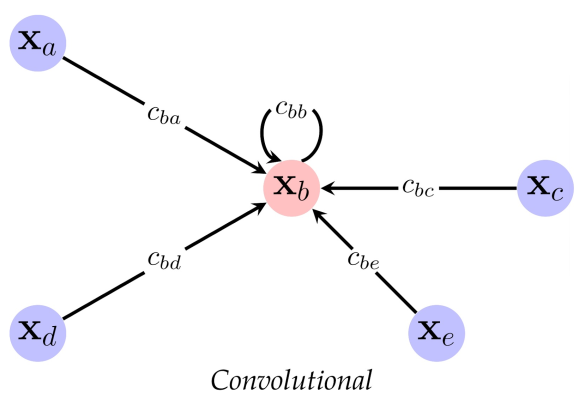












합성곱 GNN의 일반적인 방정식:
$$
\mathbf{h_i} = \phi \big(\mathbf{x_i}, \oplus_{j \in \mathcal{N}_i} c_{i,j} \psi (\mathbf{x_j}) \big)
$$

좀 더 구체적으로, Kipf와 Welling의 "Semi-Supervised Classification with Graph Convolutional Networks"(https://arxiv.org/abs/1609.02907)에 나오는 GCN을 살펴봅시다. 이는 합성곱 계수에 대칭 정규화(symmetric normalisation)를 사용하며, 폭주하는(exploding) 파라미터를 다루기 위해 재정규화(re-normalisation)를 적용합니다.

$$
\mathbf{H} = \sigma \big( \mathbf{\tilde{D}}^{-\frac{1}{2}} \mathbf{\tilde{A}} \mathbf{\tilde{D}}^{-\frac{1}{2}} \mathbf{X} \mathbf{W} \big)
$$

여기서 $\mathbf{\tilde{A}} = \mathbf{A} + \mathbf{I}$이고 $\mathbf{\tilde{D}}$는 $\mathbf{\tilde{A}}$의 차수 행렬(degree matrix)입니다.

### 💻**Task 1.1**  일반적인 합성곱 GNN 레이어의 동작이 GCN과 동일해지도록 $c_{i,j}$, $\oplus_{j \in \mathcal{N}_i}$, $\phi$를 _수학적으로_ 정의하세요. (0.5 Marks)


여기에 답을 작성하세요



### 💻**Task 1.2** 위 방정식을 바탕으로 GCNLayer를 구현하세요. (1.0 Mark)

In [ ]:
# @title [RUN] Hyperparameters GNN

NUM_EPOCHS =  100 #@param {type:"integer"}
LR         = 0.01 #@param {type:"number"}

# 필요하면 여기에 더 추가해도 된다

In [ ]:
# 아래 GCNLayer의 초기화 및 forward 메서드를 채워 넣으세요
class GCNLayer(nn.Module):
    """실습 수강생이 구현해야 할 GCN 레이어

    Args:
        input_dim (int): 입력 특징 벡터의 차원
        output_dim (int): 출력 소프트맥스 분포의 차원
        A (torch.Tensor): 2차원 인접 행렬
    """
    def __init__(self, input_dim, output_dim, A):
        super(GCNLayer, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.A = A

        A_tilde = self.A + torch.eye(A.shape[0]) # ~A = A + I I를 더해서 자기자신과 연결
        D_tilde = A.tilde.sum(dim=1)
        
        d_inv_sqrt = torch.diag(1.0 / torch.sqrt(D_tilde))  # diag함수는 벡터 -> diag 행렬 or 행렬 -> 대각선 원소 추출출
        self.adj_norm = d_inv_sqrt @ A_tilde @ d_inv_sqrt

        self.linear = nn.Linear(input_dim, output_dim)



    def forward(self, x):
        x = self.adj_norm @ x
        x = self.Linear(x)
        x = F.relu(x)
        return x


# 준지도 학습(Semi-supervised learning): 전도적(Transductive) vs 귀납적(Inductive)

GCNLayer를 호출할 때마다 우리는 앞서 MLP에서 했던 것처럼 학습/검증/테스트의 특정 부분집합을 사용하는 것이 아니라, 전체 인접 행렬과 노드 특징 행렬을 사용한다는 점에 주목하세요. 이는 서로 다른 분할(split)의 노드들이 다른 분할의 노드들과 엣지를 공유하며, 우리의 표현(representation)을 구축하려면 이러한 엣지가 필요하기 때문입니다. 따라서 GCNLayer로 수행하는 학습은 *전도적 준지도 학습(transductive semi-supervised learning)*의 한 사례인데, 모델이 데이터셋의 모든 관측치를 볼 수 있기 때문입니다. 이는 MLP에서 수행한 *귀납적(inductive)* 학습과는 다른데, 거기서는 모델이 학습 중에 오직 학습 관측치만 보고 검증/테스트 관측치는 예측을 위해서만 봅니다. **과제 중 하나를 위한 힌트** 모델이 모든 관측치와 전체 인접 행렬을 사용하더라도 모든 타깃(target)을 사용하지는 않는다는 점에 유의하는 것이 중요합니다!

### 💻**Task 1.3** 아래 코드와 다양한 `<split>_mask`들의 사용을 살펴보세요. 이들은 GCNLayer의 출력에 무엇을 하고 있으며, 왜 중요한가요? (0.5 Marks)

학습할 때 val이나 test node의 라벨을 누출되지 않고 그냥 연결성 (엣지) 만 이용하기 위해 mask split이 중요한 것 같다.


In [ ]:
# GCNLayer가 실제로 동작하는 모습을 살펴봅시다!
class SimpleGNN(nn.Module):
    """학생들이 구현한 GCNLayer를 사용하는 간단한 GNN 모델

    Args:
        input_dim (int): 입력 특징 벡터의 차원
        output_dim (int): 출력 softmax 분포의 차원
        A (torch.Tensor): 2차원 인접 행렬
    """
    def __init__(self, input_dim, output_dim, A):
        super(SimpleGNN, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.A = A
        self.gcn_layer = GCNLayer(input_dim, output_dim, A)

    def forward(self, x):
        x = self.gcn_layer(x)
        # y_hat = F.log_softmax(x, dim=1) <- 이전 버전
        y_hat = x
        return y_hat

def train_gnn_cora(X, y, mask, model, optimiser):
    model.train()
    optimiser.zero_grad()
    y_hat = model(X)[mask]
    loss = F.cross_entropy(y_hat, y)
    loss.backward()
    optimiser.step()
    return loss.data

def evaluate_gnn_cora(X, y, mask, model):
    model.eval()
    y_hat = model(X)[mask]
    y_hat = y_hat.data.max(1)[1]
    num_correct = y_hat.eq(y.data).sum()
    num_total = len(y)
    accuracy = 100.0 * (num_correct/num_total)
    return accuracy

# 학습 루프
def train_eval_loop_gnn_cora(model, train_x, train_y, train_mask,
                        valid_x, valid_y, valid_mask,
                        test_x, test_y, test_mask
                    ):
    optimiser = optim.Adam(model.parameters(), lr=LR)
    training_stats = None
    # 학습 루프
    for epoch in range(NUM_EPOCHS):
        train_loss = train_gnn_cora(train_x, train_y, train_mask, model, optimiser)
        train_acc = evaluate_gnn_cora(train_x, train_y, train_mask, model)
        valid_acc = evaluate_gnn_cora(valid_x, valid_y, valid_mask, model)
        if epoch % 10 == 0:
            print(f"Epoch {epoch} with train loss: {train_loss:.3f} train accuracy: {train_acc:.3f} validation accuracy: {valid_acc:.3f}")
        # 최종 그래프를 위해 손실과 정확도를 저장
        epoch_stats = {'train_acc': train_acc, 'val_acc': valid_acc, 'epoch':epoch}
        training_stats = update_stats(training_stats, epoch_stats)
    # 최종 테스트 성능을 살펴봅시다
    test_acc = evaluate_gnn_cora(test_x, test_y, test_mask, model)
    print(f"Our final test accuracy for the SimpleGNN is: {test_acc:.3f}")
    return training_stats

In [ ]:
# 모델과 옵티마이저를 인스턴스화
A = cora_data.get_adjacency_matrix()
X = cora_data.get_fullx()
model = SimpleGNN(input_dim=train_x.shape[-1], output_dim=7, A=A)

train_mask = cora_data.train_mask
valid_mask = cora_data.valid_mask
test_mask = cora_data.test_mask

# 학습 루프 실행
train_stats_gnn_cora = train_eval_loop_gnn_cora(model, X, train_y, train_mask,
                                          X, valid_y, valid_mask,
                                          X, test_y, test_mask
                                       )
plot_stats(train_stats_gnn_cora, name="GNN_Cora")

좋습니다, 여기서 꽤 큰 성능 향상을 얻었습니다. 학습 가능한 파라미터 수에는 변화가 없었음에도 최종 테스트 성능이 약 84%에 도달한 것을 확인할 수 있습니다. 멋지죠!

### 💻**Task 1.4** 같은 수의 파라미터를 가졌음에도 불구하고 우리의 GCNLayer가 SimpleMLP를 능가하는 이유를 본인의 말로 설명하세요. 장점과 단점은 무엇인가요? (0.5 Marks)

simpleMLP를 능가하는 이유는 주변의 node들의 정보를 얻을 수 잇기 때문이라고 생각을 한다. 주변의 node들의 정보를 받아서 그냥 더 많은 feature 정보를 얻을 수 있엇기 때문이라고 생각한다. 그리고 장점같은 경우는 풍부한 feature를 얻을 수 잇는 것 같고 그리고 파라미터 추가없이 인접행렬이라는 공짜 정보를 활용해서 성능향상을 이끌 수 있었다. 단점 같은 경우에는 너무 많은 layer를 통과하면 노드들이 비슷비슷해질 것 같다. 그리고 조금 부정적인 연관과 긍정적인 연관의 구분을 하지 못해서 이럴 경우에는 학습에 방해가 되지 않을까라는 생각이 든다.


### 💻**Task 1.5** $\mathbf{H}$의 계산에서 보이는 수용 영역(receptive field)을 확장하는 방법을 탐구하세요. 먼저, 이것을 어떻게 할 수 있을까요? 도움이 되나요? 이를 구현해 보고, GNN의 수용 영역을 늘렸을 때 성능에 미치는 효과를 관찰하세요. (0.5 Marks)

여기에 답을 작성하세요


In [ ]:
# 여기에 직접 코드를 작성해 보세요!

### 💻**Task 1.6** GCNLayer가 성능을 향상시키는 이유를 고려할 때, GCNLayer가 MLP보다 성능이 크게 떨어지도록 만들기 위해 Cora 네트워크에 어떤 변화를 줄 수 있을까요? 이 변화를 구현하고 본인의 작업을 설명하세요. (1.0 Marks)

여기에 서술형 답안을 작성하세요


In [ ]:
# 여기서 직접 코딩해 보세요!

## 그래프 수준 예측으로 넘어가기
훌륭합니다, 여러분은 GNN 레이어 개발의 기초와 노드 수준 예측 학습을 다뤘습니다.

이제 그래프 수준 예측을 살펴봅시다. 차이점을 생각해 봅시다. 각 관측치가 (일반적으로 연관된 특징 벡터로 표현되는) 노드인 것이 아니라, 이제 각 관측치가 그래프 전체입니다! 그렇게 함에 따라 우리는 첫 번째 도전 과제에 부딪힙니다. 서로 다른 크기를 가질 수 있는 그래프들을 어떻게 배치(batch)로 묶을 것인가?

# Part 2: 그래프 수준 예측

이전 절에서 여러분은 노드 수준 예측을 위한 그래프 신경망(Graph Neural Network)을 학습시켰습니다. 이제 그래프 수준 작업으로 넘어가서 **아키텍처에 어떤 변경을 해야 하는지**와 **고전적인 모델들의 한계가 무엇인지**를 이해해 봅시다.

이를 위해 우리는 [ZINC](https://arxiv.org/abs/1610.02415)를 사용할 것입니다. ZINC는 그래프 회귀(graph-regression)를 위한 데이터셋입니다. 이 데이터셋은 각각 최대 38개의 노드를 가진 약 12,000개의 분자 그래프를 포함하며, 작업은 각 분자에 대해 용해도(solubility, 스칼라 값)를 예측하는 것입니다.

[torch_geometric.dataset](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.ZINC)을 사용해 데이터셋을 로드하고 무엇을 포함하는지 확인해 봅시다:

In [ ]:
train_zinc_dataset = ZINC(root='', split='train', subset=True)
val_zinc_dataset = ZINC(root='', split='val', subset=True)
test_zinc_dataset = ZINC(root='', split='test', subset=True)

print(f"\nTrain examples: {len(train_zinc_dataset)}")
print(f"Val examples: {len(val_zinc_dataset)}")
print(f"Test examples: {len(test_zinc_dataset)}\n")

one_graph = train_zinc_dataset[0]

print(f"First graph contains {one_graph.x.shape[0]} nodes, each characterised by {one_graph.x.shape[1]} features")
print(f"Graph labels have shape: {one_graph.y.shape}")


각 그래프에 대한 정보를 저장하기 위해, 우리는 다음과 같은 ` Graph` 클래스를 만듭니다. 그래프 구조를 설명하기 위해 전체 인접 행렬을 저장하는 대신, 우리는 이를 `[2, num_edges]` 형태의 엣지 리스트로 더 효율적으로 저장한다는 점에 유의하세요.

참고: 위에서 로드한 `*_zinc_dataset`은 Graph 구조의 인스턴스가 아니지만, 그것들의 구조인 [torch_geometric.Data](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Data)는 그것과 매우 유사합니다.



In [ ]:
class Graph(object):
    def __init__(self, edge_index, x, y):
        """ 그래프 구조
            미니배치의 경우 배치 전체를 나타내는
            하나의 큰 (희소) 그래프를 저장합니다
        Args:
            x: 노드 특징  [num_nodes x num_feats]
            y: 그래프 레이블   [num_graphs]
            edge_index: 엣지 리스트 [2 x num_edges]
        """
        self.edge_index = edge_index
        self.x = x.to(torch.float32)
        self.y = y
        self.num_nodes = self.x.shape[0]

    #지금은 이것을 무시하세요, 배치 처리에 유용할 것입니다
    def set_batch(self, batch):
        """ 각 노드를 그것이 속한 그래프에 매핑하는 정수 리스트
            예: batch = [0,0,0,1,1,1,1]의 경우: 처음 3개 노드는 graph_0에 속하고
            마지막 4개 노드는 graph_1에 속합니다
        """
        self.batch = batch

    # 이 함수는 희소 텐서를 반환합니다
    def get_adjacency_matrix(self):
        """ 엣지 리스트로부터
        num_nodes x num_nodes 희소 인접 행렬을 생성합니다
        """
        return torch.sparse.LongTensor(self.edge_index,
                              # 엣지가 존재하면 1을 담는 이진 인접 행렬로 작업합니다
                              torch.ones((self.edge_index.shape[1])),
                              torch.Size((self.num_nodes, self.num_nodes))
                              )

효율성을 위해, 인접 행렬(`self.get_adjacency_matrix()`)이 (`torch.sparse.LongTensor()`를 사용하여) 희소 행렬로 저장된다는 점에 유의하세요. 이는 전체 행렬 대신, 정점들의 인덱스와 각 엣지에 해당하는 값(가중치)만 저장한다는 것을 의미합니다. 이는 대부분의 원소가 0인 텐서를 저장하는 데 있어 많은 메모리를 절약해 줍니다.

희소 텐서 `x`를 밀집(dense) 텐서로 변환해야 한다면 `x.to_dense()`를 사용할 수 있습니다. 게다가 많은 연산이 [torch.sparse](https://pytorch.org/docs/stable/sparse.html)를 통해 희소 텐서에 대해 직접 지원됩니다(예: 희소 행렬을 희소/밀집 행렬과 곱하는 `torch.sparse.mm()`).

`networkx` 라이브러리를 사용하여 그래프를 시각화해 봅시다.

*이를 어떻게 하는지 보여주는 것은 이 실습의 범위를 벗어나므로, 함수는 여러분을 위해 전부 작성되어 있습니다. 하지만 이에 대해 더 알아보려면 [여기](https://networkx.org/documentation/stable/tutorial.html)에서 확인할 수 있습니다.*

In [ ]:
gallery([one_graph], labels=np.array([one_graph.y]), max_fig_size=(8,10))

# 그래프 데이터를 위한 미니배치 처리

이제 우리는 여러 개의 그래프를 다루고 있으므로, 계산을 가능한 한 효율적으로 만들기 위해 이들을 미니배치에 어떻게 저장할지 알아내야 합니다. 어떤 유형의 데이터에서는 샘플들을 미니배치로 쌓는 것이 사소한 작업입니다. 예를 들어, $32\times32$ 픽셀의 이미지들은 같은 차원을 가지므로 배치로 묶기 쉽습니다($batch\_{size}\times32\times32$ 차원의 텐서를 얻음). 반면, 그래프들은 서로 다른 형태의 인접 행렬을 가진 서로 다른 크기로 존재합니다:

In [ ]:
print(f'First graph : {train_zinc_dataset[0].x.shape} with adjacency {(train_zinc_dataset[0].num_nodes, train_zinc_dataset[0].num_nodes)}')
print(f'Second graph: {train_zinc_dataset[1].x.shape} with adjacency {(train_zinc_dataset[1].num_nodes, train_zinc_dataset[1].num_nodes)}')
print(f'Third graph : {train_zinc_dataset[2].x.shape} with adjacency {(train_zinc_dataset[2].num_nodes, train_zinc_dataset[2].num_nodes)}')


이에 대한 한 가지 해결책은 미니배치 내 모든 그래프의 합집합으로서 하나의 *희소* 그래프를 다음과 같이 생성하는 것입니다:

1. 모든 그래프의 모든 노드에 대한 특징 $x$를 쌓습니다
2. 모든 그래프의 모든 노드에 대한 레이블 $y$를 쌓습니다
3. 모든 인접 행렬 $A_i$를 새로운 인접 행렬의 대각 블록으로 쌓습니다

이렇게 하면, $\sum_{i=1}^{B}|V_i|$개의 노드를 포함하는 새로운 그래프를 얻게 됩니다. 여기서 $B$는 배치 크기(batch_size)이고 $|V_i|$는 그래프 $i$의 노드 수를 나타냅니다. **어떤** 엣지도 서로 다른 그래프의 노드들을 연결하지 않으므로, 정보 전파는 우리가 저장하는 방식에 영향을 받지 않는다는 점에 유의하세요.

<center>
<img src="https://drive.google.com/uc?export=view&id=1RwI0CYA57S0OgLxgHgV6PBFNG9tnGvGR" width="500">
</center>

<center>
<img src="https://drive.google.com/uc?export=view&id=1Ux65wTJLXCfJ4TI4Up4mCHkaSja8NgrJ" width="500">
</center>


보시다시피, 결과 행렬은 많은 0을 포함하므로(희소), 인접 행렬을 희소 텐서로 저장하기로 한 우리의 선택은 실제로 효율성을 가져다줄 수 있습니다.

지금까지 우리는 그래프들을 효율적으로 처리할 수 있도록 미니배치에 저장하는 방법을 갖추었습니다.

하지만 우리는 또한 이 구조에서 정보를 추출하여, 그것이 포함하는 그래프들을 복원할 수 있어야 합니다. 이를 위해 각 노드가 어떤 초기 그래프에 속하는지 기억해야 합니다.

우리는 배치 그래프 내의 각 노드를 그것이 속한 초기 그래프에 매핑하는 인덱스 리스트 `(self.batch)`를 저장함으로써 이를 수행할 것입니다. 예를 들어 `batch=[0,0,0,1,1,2,2,2]`는 처음 3개 노드가 $G_0$에 속하고, 다음 2개 노드가 $G_1$에 속하며, 마지막 3개 노드가 $G_2$에 속함을 나타냅니다.



### 💻 **Task 2.1:** 다음에서 여러분은 mini_batch 함수를 구현해야 합니다. (1.5 Marks)

In [ ]:
def create_mini_batch(graph_list: List[Graph]) -> Graph:
    """ 여러 그래프의 배치로부터 희소 그래프를 구성합니다
    Args:
        graph_list: 한 배치에 포함된 Graph 객체들의 리스트
    Returns:
        전체 배치를 나타내는 하나의 큰 (희소) Graph
    """
    #첫 번째 그래프를 구조에 삽입합니다
    batch_edge_index = graph_list[0].edge_index
    batch_x = graph_list[0].x
    batch_y = graph_list[0].y
    batch_batch = torch.zeros((graph_list[0].num_nodes), dtype=torch.int64)
    # ============ 여기에 코드를 작성하세요 =============
    # 추가 변수가 필요할 수 있습니다
    # ==========================================

    #나머지 그래프들을 구조에 이어 붙입니다
    for idx, graph in enumerate(graph_list[1:]):
        # ============ 여기에 코드를 작성하세요 =============
        # 특징(feature)들을 연결합니다
        # batch_x = ...
        # 레이블들을 연결합니다
        # batch_y = ...

        # 인접 행렬을 블록 대각 행렬로 연결합니다
        # batch_edge_index = ...
        # ==========================================

        # ============ 여기에 코드를 작성하세요 =============
        # 배치 그래프 내의 노드들을 그들이 속한 그래프로 매핑하는
        # 인덱스 배열을 생성합니다
        # 새 노드들과 그들이 속한 그래프(idx+1) 사이의 매핑을 지정합니다
        # batch_batch = ...
        # ==========================================
        pass
    #큰 희소 그래프를 생성합니다
    batch_graph = Graph(batch_edge_index, batch_x, batch_y)
    #인덱스 배열을 Graph 구조에 부착합니다
    batch_graph.set_batch(batch_batch)
    return batch_graph

In [ ]:
#@title Visualize the mini-batching for a small list of batch_size=3 graphs.
# 시각화된 세 개의 그래프는 방향 그래프(directed)임에 유의하라.
# 따라서 (시각화에서는 무방향 그래프처럼 그려졌더라도)
# 인접 행렬은 비대칭(non-symmetric)이 된다

# 시각화를 위해 직접 설계한 3개의 랜덤 그래프
graph1 = Graph(x=torch.rand((3,32)),
               y=torch.rand((1)),
               edge_index=torch.tensor([[0,0,0,1,1,1,2,2,2],[0,1,2,0,1,2,0,1,2]]))
graph2 = Graph(x=torch.rand((5,32)),
               y=torch.rand((1)),
               edge_index=torch.tensor([[0,0,0,0,0,1,1,1,2,1,2,3,4], [0,1,2,3,4,2,3,4,4,0,0,0,0]]))
graph3 = Graph(x=torch.rand((4,32)),
               y=torch.rand((1)),
              edge_index=torch.tensor([[0,1,2,3],[1,2,3,0]]))
list_graphs = [graph1, graph2, graph3]

# 이 3개의 그래프로부터 미니 배치를 생성한다
batch_sample = create_mini_batch(list_graphs)

# 이 그래프 배치로부터 구성된 새로운 그래프에 대한 통계를 출력한다
print(f"Batch number_of_nodes: {batch_sample.num_nodes}")
print(f"Batch features shape: {batch_sample.x.shape}")
print(f"Batch labels shape: {batch_sample.y.shape}")

print(f"Batch adjacency: ")
print_color_numpy(batch_sample.get_adjacency_matrix().to_dense().numpy(), list_graphs)

gallery([graph1, graph2, graph3, batch_sample], max_fig_size=(20,6), special_color=True)
print(f"And we also have access to which graph each node belongs to {batch_sample.batch}\n")


# 정보 집계를 위한 Scatter



강의에서 배웠듯이, 노드 수준 표현(node-level representation)으로부터 정보를 집계하여 그래프 수준 예측(graph-level prediction)을 얻는 간단한 방법은 (max/mean/sum) 풀링(pooling)이다. 이는 `scatter_mean`, `scatter_max`, `scatter_sum`과 같은 연산을 포함하는 [`torch_scatter`](https://pytorch-scatter.readthedocs.io/en/1.3.0/functions/mean.html) 라이브러리를 사용하여 효율적으로 얻을 수 있다.

 `scatter_*`는 입력으로 텐서 하나와 인덱스 배열을 받아, 그 배열에 지정된 인덱스에 저장된 텐서의 정보를 풀링한다.

`scatter_sum(array, index)`에 대한 시각화:

\\

<!-- <center> -->
<img src="https://drive.google.com/uc?export=view&id=16E9Nyd-mPdYBWm923joWKJx4JR8c8pCz" width="300">
<!-- </center> -->

### 💻 **Task 2.2:** 배치 내 모든 노드의 임베딩에 접근할 수 있을 때, `scatter_*`를 사용하여 배치 내 각 그래프에 대한 그래프 임베딩을 생성하라 (0.5 Marks)

In [ ]:
array = torch.tensor([13, 21, 3, 7, 11, 20, 2])
index = torch.tensor([0,1,1,0,2,0,1])

aggregate_sum = scatter_sum(array, index, dim=0)
aggregate_mean = scatter_mean(array, index, dim=0)
aggregate_max, aggregate_argmax = scatter_max(array, index, dim=0)

print("Let's inspect what different scatter functions compute: ")
print(f"sum aggregation: {aggregate_sum}")
print(f"mean aggregation: {aggregate_mean}")
print(f"max aggregation: {aggregate_max}\n")

batch_zinc = create_mini_batch(train_zinc_dataset[:3])
# ============ 여기에 코드를 작성하세요 =============
# 그래프 배치의 노드 특징(batch_zinc.x)과
# 각 노드가 어떤 그래프에 속하는지를 나타내는 인덱스 리스트가 주어졌을 때
# scatter_*를 적용하여 배치 내 각 그래프에 대한 그래프 임베딩을 구하세요
# 모든 함수(scatter_mean/scatter_max/scatter_sum)를 자유롭게 시험해 볼 수 있습니다

# node_emb = ...
# node_batch = ...
# graph_emb = ...
# ==========================================
print(node_emb.shape)
print(graph_emb.shape)


✅ 그러니까 지금까지 우리는 다음을 배웠다
1. 그래프들의 배치를 효율적인 방식으로 저장하는 방법
2. scatter 연산이 어떻게 동작하는지, 그리고 이를 사용해 노드 수준 표현으로부터 그래프 수준 표현을 추출하는 방법.

지금까지 배운 것을 그래프 신경망(Graph Neural Network) 모델에 통합해 보자.

# 그래프 수준 회귀(graph-level regression)를 위한 그래프 신경망

In [ ]:
# @title [RUN] Hyperparameters GIN

BATCH_SIZE = 128 #@param {type:"integer"}
NUM_EPOCHS =   30#@param {type:"integer"}
HIDDEN_DIM =   64#@param {type:"integer"}
LR         = 0.001 #@param {type:"number"}

#필요하다면 여기에 더 추가할 수 있다

우리는 Cora에서 사용했던 것과 유사한 그래프 신경망 모델을 다음과 같은 수정 사항과 함께 설계할 것이다:
* 노드 수준 예측 대신 그래프 수준 예측
* 분류(classification) 대신 회귀(regression)
* *증명 가능하게 더 강력한 아키텍처* $^\dagger$를 얻기 위해, GCN 레이어를 넘어 대신 [**GIN 레이어**](https://arxiv.org/abs/1810.00826)를 구현할 것이다.

$^\dagger$*이것이 무엇을 의미하는지는 본 실습의 마지막 섹션에서 엄밀하게 정의할 것이다.*

GIN 레이어의 간단한 한 가지 구현체는 다음 메시지 전달(message passing) 방정식에 따라 그래프를 처리하며, 여기서 $\epsilon_k$는 학습 가능한 스칼라이다

\begin{equation}
X^{k+1}= \text{MLP}_k\big(AX^k + (1+\epsilon_k)X^k\big)
\end{equation}

### 💻 **Task 2.3:** 대부분의 코드는 제공되어 있지만, 위에 제시된 핵심 메시지 전달 방정식을 구현하는 빠진 부분을 채워 넣어야 한다. (1 Mark)

In [ ]:
class GINLayer(nn.Module):
    """MLP(AX + (1+eps)X)를 구현하는 단일 GIN 레이어"""
    def __init__(self, in_feats: int, out_feats: int, hidden_dim: int, eps: float=0.0):
        super(GINLayer, self).__init__()
        self.in_feats = in_feats
        self.out_feats = out_feats
        # ============ 여기에 코드를 작성하세요 =============
        # epsilon은 학습 가능한 파라미터여야 합니다
        # self.eps = ...
        # =========================================
        self.linear1 = nn.Linear(self.in_feats, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, self.out_feats)

    def forward(self, x, adj_sparse):
        # ============ 여기에 코드를 작성하세요 =============
        # GIN에서처럼 이웃들을 집계합니다: (AX + (1+eps)X)
        # x = ...

        # 특징들을 사영합니다 (MLP_k)
        # out =
        # =========================================
        return out

위의 GIN 레이어를 사용하여, 그래프 회귀 과제를 풀기 위해 `num_layers`개의 GINLayer로 구성된 신경망을 설계해 보자

### 💻 **Task 2.4:** 코드는 제공되어 있다. 여러분이 해야 할 일은 노드 표현으로부터 그래프 표현을 생성하는 코드를 채워 넣는 것뿐이다 (1 Mark)

In [ ]:
from torch.nn.modules.linear import Linear
class SimpleGIN(nn.Module):
    """
    https://arxiv.org/abs/1810.00826 에서와 같이
    GIN 레이어들을 포함하는 그래프 신경망입니다
    그래프 수준 표현을 얻기 위해 사용되는 readout 함수는
    그래프 내 노드들의 합일 뿐입니다

    Args:
        input_dim (int): 입력 특징 벡터의 차원
        output_dim (int): 출력 소프트맥스 분포의 차원
        num_layers (int): 레이어의 수
    """
    def __init__(self, input_dim, output_dim, hidden_dim, num_layers=2, eps=0.0,
                 molecular=True):
        super(SimpleGIN, self).__init__()
        self.num_layers = num_layers # num_layers>=2 를 선택하세요
        self.molecular = molecular
        # ZINC 데이터셋의 노드들은 하나의 정수(원자 범주)로 특징지어집니다
        # nn.Embedding을 사용하여 범주형 특징으로부터 임베딩을 생성합니다
        if self.molecular:
            self.embed_x = Embedding(28, hidden_dim)
        else:
            self.embed_x = Linear(input_dim, hidden_dim)

        # SimpleMLP 모델에서의 nn.Linear 대신,
        # 이제는 각기 다른 파라미터를 가진 (num_layers)개의 GINLayer(들)이 있습니다
        self.layers = [GINLayer(hidden_dim, hidden_dim, hidden_dim, eps) for _ in range(num_layers-1)]
        self.layers += [GINLayer(hidden_dim, output_dim, hidden_dim, eps)]
        self.layers = nn.ModuleList(self.layers)

    def forward(self, graph):
        adj_sparse = graph.get_adjacency_matrix()
        if self.molecular:
            x = self.embed_x(graph.x.long()).squeeze(1)
        else:
            x = self.embed_x(graph.x)

        for i in range(self.num_layers-1):
          x = self.layers[i](x, adj_sparse)
          x = F.relu(x)
        x = self.layers[-1](x, adj_sparse)

        # ============ 여기에 코드를 작성하세요 =============
        # 그래프 수준 표현은 합을 사용하여 노드들의 정보를 풀링함으로써 얻어집니다
        # y_hat = ...
        # =========================================

        y_hat = y_hat.squeeze(-1)
        #시각화를 위해 최종 노드 임베딩도 함께 반환합니다
        return y_hat, x

이제 가지고 놀 수 있는 제대로 된 그래프 네트워크가 생겼으니, 우리의 미니 배치 구현이 올바른지 확인해 보자. 이를 위해, 개별 그래프들에 대해 코드를 실행한 결과와 전체 배치에 대해 직접 실행한 결과가 동일한지를 확인하는 단위 테스트(unit test)를 제공한다:

In [ ]:
#@title [RUN] Unit test for mini-batch implementation
def unit_test_mini_batch(batch):
  model = SimpleGIN(input_dim=batch[0].x.size()[-1], output_dim=1, hidden_dim=HIDDEN_DIM, num_layers=4)

  graph_batch = create_mini_batch(batch)
  out_batch, _ = model(graph_batch)

  for i in range(BATCH_SIZE):
    batch_i = create_mini_batch([batch[i]])
    out_i, node_emb_i = model(batch_i)
    assert(np.abs(out_i.detach().numpy() - out_batch[i].detach().numpy()).mean() <1e-5 )
  print("Congrats 😊 !! Everything seems all right!")

In [ ]:
#@title Run unit test for mini-batch implementation
batch = train_zinc_dataset[:BATCH_SIZE]
unit_test_mini_batch(batch)

In [ ]:
def train(dataset, model, optimiser, epoch, loss_fct, metric_fct, print_every):
    """ 모델을 한 에폭(epoch) 동안 학습시킨다
    """
    model.train()
    num_iter = int(len(dataset)/BATCH_SIZE)
    for i in range(num_iter):
        batch_list = dataset[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        batch = create_mini_batch(batch_list)
        optimiser.zero_grad()
        y_hat, _ = model(batch)
        loss = loss_fct(y_hat, batch.y)
        metric = metric_fct(y_hat, batch.y)
        loss.backward()
        optimiser.step()
        if (i+1) % print_every == 0:
          print(f"Epoch {epoch} Iter {i}/{num_iter}",
                    f"Loss train {loss.data}; Metric train {metric.data}")
    return loss, metric

def evaluate(dataset, model, loss_fct, metrics_fct):
    """ 데이터셋에서 모델을 평가한다
    """
    model.eval()
    # 실전에서는 주의하라. 이런 방식으로 하면 len(dataset)%BATCH_SIZE != 0 일 때
    # 검증(validation) 분할에서 일부 예제를 잃게 된다.
    # 이것을 어떻게 고칠 수 있을지 생각해 보라!
    num_iter = int(len(dataset)/BATCH_SIZE)
    metrics_eval = 0
    loss_eval = 0
    for i in range(num_iter):
        batch_list = dataset[i*BATCH_SIZE:(i+1)*BATCH_SIZE]
        batch = create_mini_batch(batch_list)
        y_hat, _ = model(batch)
        metrics = metrics_fct(y_hat, batch.y)
        loss = loss_fct(y_hat, batch.y)

        metrics_eval += metrics.data
        loss_eval += loss.data
    metrics_eval /= num_iter
    loss_eval /= num_iter
    return loss_eval, metrics_eval

In [ ]:
def train_eval(model, train_dataset, val_dataset, test_dataset,
               loss_fct, metric_fct, print_every=1):
    """ 모델을 NUM_EPOCHS 에폭 동안 학습시킨다
    """
    #우리의 옵티마이저를 인스턴스화한다
    optimiser = optim.Adam(model.parameters(), lr=LR)
    training_stats = None

    #초기 평가 (학습 전)
    val_loss, val_metric = evaluate(val_dataset, model, loss_fct, metric_fct)
    train_loss, train_metric = evaluate(train_dataset[:BATCH_SIZE], model,
                                        loss_fct, metric_fct)
    epoch_stats = {'train_loss': train_loss, 'val_loss': val_loss,
                      'train_metric': train_metric, 'val_metric': val_metric,
                      'epoch':0}
    training_stats = update_stats(training_stats, epoch_stats)

    for epoch in range(NUM_EPOCHS):
        if isinstance(train_dataset, list):
            random.shuffle(train_dataset)
        else:
            train_dataset.shuffle()
        train_loss, train_metric = train(train_dataset, model, optimiser, epoch,
                                        loss_fct, metric_fct, print_every)
        val_loss, val_metric = evaluate(val_dataset, model, loss_fct, metric_fct)
        print(f"[Epoch {epoch+1}]",
                    f"train loss: {train_loss:.3f} val loss: {val_loss:.3f}",
                    f"train metric: {train_metric:.3f} val metric: {val_metric:.3f}"
              )
        # 최종 플롯을 위해 손실과 계산된 지표를 저장한다
        epoch_stats = {'train_loss': train_loss, 'val_loss': val_loss,
                      'train_metric': train_metric, 'val_metric': val_metric,
                      'epoch':epoch+1}
        training_stats = update_stats(training_stats, epoch_stats)

    test_loss, test_metric = evaluate(test_dataset, model,  loss_fct, metric_fct)
    print(f"Test metric: {test_metric:.3f}")
    return training_stats

이제 우리 모델을 학습시키고 그 결과를 즐길 시간이다.

In [ ]:
# 우리의 GIN 모델을 인스턴스화한다
model_simple_gin = SimpleGIN(input_dim=batch_zinc.x.size()[-1], output_dim=1, hidden_dim=HIDDEN_DIM, num_layers=4, eps=0.1)
out, _ = model_simple_gin(batch_zinc)
print(out.detach().numpy())

In [ ]:
#GIN 모델을 학습시킨다:
train_stats_simple_gin_zinc = train_eval(model_simple_gin, train_zinc_dataset, val_zinc_dataset,
                                  test_zinc_dataset, loss_fct=F.mse_loss,
                                  metric_fct=F.mse_loss, print_every=150)
plot_stats(train_stats_simple_gin_zinc, name='Simple_GIN_ZINC', figsize=(5, 10))

원본 [논문](https://arxiv.org/pdf/1810.00826.pdf)에서 소개된 전체 GIN 아키텍처는 예측을 위해 최종 출력만 사용하지 않습니다. 대신, 모든 중간 레이어의 표현으로부터 그래프 표현을 생성합니다:

\begin{equation}
h_G = CONCAT\big(\oplus_{v \in G}\{h_v^{(k)}\}| k=0,1..(K-1) \big)
\end{equation}

여기서 $\oplus_{v \in G}\{h_v^{(k)}\}$는 레이어 $k$에서의 그래프 수준 표현을 나타내며, 이는 모든 노드 $v \in G$의 표현을 합산하여 얻습니다.

\\

### 💻 **Task 2.5:** 위에서 설명한 전체 아키텍처를 구현하세요. (1 Mark)

In [ ]:
class GIN(nn.Module):
    """
    https://arxiv.org/abs/1810.00826 에서와 같이 GIN 레이어를 포함하는
    그래프 신경망
    그래프 수준 표현을 얻기 위해 사용되는 readout 함수는
    (JK-Net에서와 같이) 여러 레이어의 예측을 집계한다

    Args:
    input_dim (int): 입력 특징 벡터의 차원
    output_dim (int): 출력 softmax 분포의 차원
    num_layers (int): 레이어 수
    """
    def __init__(self, input_dim, output_dim, hidden_dim, num_layers=2, eps=0.0, \
                 molecular=True):
        super(GIN, self).__init__()
        self.num_layers = num_layers
        self.molecular = molecular
        # ZINC 데이터셋의 노드는 하나의 정수(원자 카테고리)로 특징지어진다
        # nn.Embedding을 사용하여 범주형 특징으로부터 임베딩을 생성할 것이다
        if self.molecular:
            self.embed_x = Embedding(28, hidden_dim)
        else:
            self.embed_x = Linear(input_dim, hidden_dim)

        # ============ 여기에 코드를 작성하세요 =============
        # 이전과 동일해야 한다 (GINLayer들의 nn.ModuleList)
        # self.layers = ...

        # 연결된 중간 표현들로부터 예측을 계산하는 레이어
        # self.pred_layers = ...
        # =========================================

    def forward(self, graph):
        adj_sparse = graph.get_adjacency_matrix()
        if self.molecular:
            x = self.embed_x(graph.x.long()).squeeze(1)
        else:
            x = self.embed_x(graph.x)

        # ============ 여기에 코드를 작성하세요 =============
        # 새로운 readout 함수로 순전파를 수행하세요
        for i in range(self.num_layers-1):
            # x = ...
            pass
        # y_hat = ...
        pass
        # =========================================
        # 최종 노드 임베딩도 함께 반환한다 (시각화를 위해)
        return y_hat, x

In [ ]:
model_gin = GIN(input_dim=batch_zinc.x.size()[-1], output_dim=1, hidden_dim=HIDDEN_DIM, num_layers=4, eps=0.1)
out, _ = model_gin(batch_zinc)
print(out.detach().numpy())

# GIN 모델 학습:
train_stats_gin_zinc = train_eval(model_gin, train_zinc_dataset, val_zinc_dataset,
                                  test_zinc_dataset, loss_fct=F.mse_loss,
                                  metric_fct=F.mse_loss, print_every=150)
plot_stats(train_stats_gin_zinc, name='GIN_ZINC', figsize=(5, 10))

# Part 3: 그래프 신경망의 표현력 (Expressive Power of Graph Neural Networks)



여러분은 이미 그래프 신경망이 그래프 데이터를 처리하는 강력한 도구임을 확신하고 있을 것입니다. 그러나 여러분이 알아두어야 할 몇 가지 이론적으로 입증된 한계가 존재합니다. 지금부터 이 실습에서 여러분의 목표는 **이러한 한계를 이해하고 극복하는 것**입니다.

다음에서는 구별하기 어려운 2개의 그래프를 살펴보고, GNN이 풀 수 없는 문제가 무엇이며 왜 이런 일이 일어나는지 이해하고자 합니다.

In [ ]:
#@title [RUN] Hard to distinguish graphs
def gen_hard_graphs_WL():

  x1 = torch.ones((10,1))
  edge_index1 = torch.tensor([[1, 1, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10],
                 [2, 5, 1, 3, 2, 4, 6, 3, 5, 1, 4, 3, 7, 10, 6, 8, 7, 9, 8, 10, 6, 9]])-1
  y1 = torch.tensor([1])

  x2 = torch.ones((10,1))
  edge_index2 = torch.tensor([[1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10],
                 [2, 6, 1, 3, 7, 2, 4, 10, 3, 5, 4, 6, 1, 5, 2, 8, 7, 9, 8, 10, 3, 9]])-1
  y2 =  torch.tensor([2])

  graph1 = Graph(x=x1, edge_index=edge_index1, y=y1)
  graph2 = Graph(x=x2, edge_index=edge_index2, y=y2)
  return [graph1, graph2]

In [ ]:
hard_graphs = gen_hard_graphs_WL()
gallery(hard_graphs, labels=["A","B"], max_fig_size=(10,5))

이 그래프들을 우리의 GIN 신경망을 사용하여 인코딩해 봅시다.

In [ ]:
hard_batch = create_mini_batch(hard_graphs)
out, node_emb = model_simple_gin(hard_batch)

# batch의 node_emb를 개별 그래프로 분리
node_emb = node_emb.detach().numpy()
node_emb_split=[node_emb[:hard_graphs[0].num_nodes], node_emb[hard_graphs[0].num_nodes:]]

# 노드 표현을 색상을 나타내는 [0,1] 범위의 정수로 인코딩
node_emb_split = hash_node_embedings(node_emb_split)


gallery(hard_graphs, node_emb=node_emb_split, max_fig_size=(10,5))


위 시각화에서 색상은 모델이 예측한 노드 임베딩을 나타냅니다. 강의에서 배운 것처럼, 그래프 수준 표현을 얻기 위해 우리는 *순열 불변(permutation invariant)* 함수를 사용하여 노드 임베딩을 풀링합니다. 이는 색상의 다중집합(multiset)이 그래프 임베딩을 결정한다는 것을 의미합니다. 더 정확히 말하면, 두 그래프가 동일한 색상 다중집합으로 인코딩되면 최종 그래프 표현은 동일해집니다.
이는 그래프 수준의 관점에서 위에 표시된 2개의 그래프가 동일하다는 것을 의미합니다. 그러나 사람에게는 이것이 사실이 아니라는 것이 명백합니다.

**왜 이런 일이 일어나는 걸까요 ❓**

5-레이어 GNN이 노드 임베딩을 어떻게 계산하는지 살펴봅시다.



<!-- <center> -->
<img src="https://drive.google.com/uc?export=view&id=1Jt6zJVApmgS9VFbcKpzxOoBtrxos55iu" width="1000">
<!-- </center> -->

두 그래프에 대해 계산 네트워크가 5단계에 걸쳐 어떻게 생겼는지 살펴보면, 그것들이 본질적으로 매우 비슷하게 보인다는 것을 관찰할 수 있습니다. 우리는 알아챌 수 있지만 GNN은 알아채지 못하는 **중요한** 차이는, 5개의 전파(propagation) 레이어를 거친 후 한 그래프(왼쪽)에서는 우리가 출발한 동일한 노드에 도달하는 반면, 다른 그래프(오른쪽)에서는 다른 노드에 도달한다는 것입니다. 구조적 관점에서 2개의 노드는 동일하므로, GNN은 그것들 사이의 차이를 인식하지 못한 채 동일하게 인코딩하게 됩니다.

다음 절에서는 이를 어떻게 완화할 수 있는지, 그리고 이 문제가 제기하는 실질적인 함의가 무엇일 수 있는지 찾아보려고 합니다.

# 표현력 향상시키기 (Improving the expressive power)

위 예제에서 보았듯이, GIN(그리고 일반적으로 MPNN)은 비동형(non-isomorphic) 그래프의 임의의 쌍을 구별할 수 없습니다. 이를 바탕으로, 우리는 어떤 그래프 쌍을 구별할 수 있거나 없는지에 따라 GNN 모델의 위계(hierarchy)를 고안할 수 있습니다.

**정의.** *어떤 GNN 모델 B가 다른 모델 A보다 엄밀하게 더 강력하다(strictly more powerful)고 말하는 것은, B가 A가 구별할 수 있는 모든 속성 그래프(attributed graph) 쌍을 구별할 수 있고, 동시에 B는 구별할 수 있지만 A는 구별할 수 없는 속성 그래프 쌍이 존재하는 경우이다.*

이 절에서는 GIN보다 더 강력한 GNN 모델을 구축하고, 이를 경험적으로 평가할 수 있는 합성(synthetic) 과제를 설계할 것입니다. 그런 다음, 여러분의 모델이 실제로 더 강력하다는 것을 수학적으로 증명하도록 요청받게 됩니다.

### 💻**Task 3.1:** 더 우수한 표현력을 가진 모델이 GIN보다 더 잘 수행해야 하는 그래프 분류 또는 회귀 과제를 구성하세요. 데이터셋을 학습(training), 검증(validation), 테스트(testing) 부분집합으로 분할하세요. (1 Mark)

힌트: GIN이 구별할 수 없는 그래프 쌍의 예를 더 찾아내어 데이터셋으로 일반화해 보세요.

In [ ]:
# ============ 여기에 코드를 작성하세요 =============
# 데이터셋을 구성하세요.
# =========================================

### 💻**Task 3.2:** GIN의 표현력을 증가시킬 수 있는 특징 증강(feature augmentation) 절차를 생각해 보세요. 합성 과제에서 GIN + 특징 증강이 GIN보다 더 나은가요? 결과를 설명하세요. (1 Mark)

그 위에 GIN 모델을 적용했을 때 더 높은 판별력(discriminativity)으로 이어질 수 있는, 그래프에 관한 추가 정보로 초기 그래프 특징을 어떻게 증강할 수 있을까요?

In [ ]:
# ============ 여기에 코드를 작성하세요 =============
# 특징 증강(Feature Augmentation)을 적용한 GIN을 구현하세요
# =========================================

In [ ]:
# ============ 여기에 코드를 작성하세요 =============
# 이 새로운 데이터셋에서 GIN과 비교하여 모델을 평가하세요.
# =========================================

### 💻**Task 3.3:** GIN + 특징 증강이 실제로 바닐라 GIN보다 엄밀하게 더 강력하다는 것을 수학적으로 증명하세요. (1 Mark)

더 강력하다는 우리의 정의에 따라, 우리는 두 단계 접근법을 채택합니다. 첫째, 여러분의 모델이 적어도 GIN만큼 강력하다는 것(즉, GIN이 구별할 수 있는 모든 쌍을 또한 구별할 수 있다는 것)을 증명하고, 둘째, 여러분의 모델이 GIN에 비해 추가적인 쌍도 구별할 수 있다는 것을 증명합니다.

GIN이 수행하는 지역 집계(local aggregation)를 보다 추상적으로 $x_v^{k+1} = f_{\text{GIN}}(x_v^k, \{\{ x_u^k \mid u \in \mathcal{N}(v)\}\})$로 쓰겠습니다. 여기서 $\{\{ ... \}\}$는 다중집합(multiset)을 나타내고 $x_v^k$는 레이어 $k$에서의 노드 $v$의 특징을 나타냅니다. $f_{\text{GIN}}$이 단사(injective)일 때 GIN이 최대로 표현력이 높다는 점에 주목하세요. 왜냐하면 이는 서로 다른 이웃을 서로 다른 임베딩으로 매핑할 수 있게 하여 더 높은 판별력으로 이어지기 때문입니다. 우리는 $f_{\text{GIN}}$을 단사로 만드는 매개변수 집합이 존재한다는 것을 사실(즉, 증명 없이)로 사용할 것입니다.

따라서 증명의 첫 번째 부분에서는 다음 단계들을 증명하세요:

**Step 1:** 단사 레이어를 가진 GIN 모델의 레이어 $k$에서의 노드 $v$의 특징을 $x_v^k$로 나타냅니다. 마찬가지로, $k=0$에서 증강된 특징을 가지며 단사 레이어를 가진 두 번째 GIN 모델의 특징을 $y_v^k$로 나타냅니다. 임의의 두 그래프에서 온 임의의 두 노드 $v, u$에 대해, 만약 $y_v^k = y_u^k$이면 $x_v^k = x_u^k$임을 귀납법으로 증명하세요.

**Step 2:** 임의의 두 그래프 $\mathcal{G_1}, \mathcal{G_2}$에 대해, 만약 $\{\{x_v^{k} \mid  v \in V_{\mathcal{G_1}} \}\} \neq \{\{x_u^{k} \mid  u \in V_{\mathcal{G_2}}\}\}$이면, $\{\{y_v^{k} \mid  v \in V_{\mathcal{G_1}} \}\} \neq \{\{y_u^{k} \mid  u \in V_{\mathcal{G_2}}\}\}$임을 증명하세요.

***증명.*** 여기에 증명을 작성하세요

이제 위에서 제안한 모델을 실세계 환경에서 테스트해 봅시다.

### 💻**Task 3.4:** ZINC에서 GIN + 특징 증강을 평가하고 그 결과를 바닐라 GIN과 비교하세요. 여러분의 모델이 더 나은가요? 어느 경우이든, 여러분이 얻은 결과를 설명하세요. (0.5 Marks)

In [ ]:
# ============ 여기에 코드를 작성하세요 =============
# ZINC 데이터셋에서 모델을 평가하세요
# =========================================


### 💻**Task 3.5:** 메시지 패싱을 넘어서 (Beyond message passing) (2.5 Marks)

우리는 추가 점수를 위한 개방형(open-ended) 과제로 이 실습을 마무리하겠습니다.

지금까지 우리는 그래프의 초기 특징에 추가 특징을 더함으로써 표현력을 증가시키는 것만 살펴보았습니다. 대안은 모델의 계산 그래프(computational graph)를 수정하는 것입니다. 다시 말해, 우리는 강의와 이 실습에서 본 전통적인 메시지 패싱 접근법을 넘어서는 계산을 수행할 수 있으며, 이는 궁극적으로 향상된 판별력으로 이어질 수 있습니다.

1.   노드 간의 일반적인 메시지 패싱을 넘어섬으로써 GIN보다 엄밀하게 더 표현력이 높은 모델을 설계하세요.  
2.   여러분의 모델이 실제로 GIN보다 엄밀하게 더 강력하다는 것을 증명하세요.
3.   여러분 모델의 레이어가 순열 등변(permutation equivariant)임을 증명하고 이를 확인하는 테스트를 작성하세요.
4.   ZINC에서 여러분의 모델을 평가하세요. 위의 GIN 및 GIN + 증강 특징 모델과 비교하면 어떤가요?
5.   여러분 솔루션의 계산 복잡도(computational complexity)를 논의하세요. 메시지 패싱 접근법의 복잡도와 비교하면 어떤가요? 여러분 솔루션의 복잡도를 개선할 수 있나요?

